In [66]:
import pandas as pd

from functions.functions import corr_heatmap_xy

In [67]:
end_year = 2024
region_analysis = "Europe_and_North_America_and_Japan"

global_universe = pd.read_csv(f"../data/Global_Universe/Global_Universe_{region_analysis}_{end_year}.csv")
global_universe = global_universe[global_universe["month"] == 12].copy()


#Uncomment below for observing futre performance (note im not sure if when shifting the data is matches to gvkey)


# # Accounting columns (t)
# accounting_columns = list(global_universe.columns[14:24])




# if "date" in global_universe.columns:
#     global_universe["date"] = pd.to_datetime(global_universe["date"], errors="coerce")

# required_cols = {"gvkey", "date"}
# missing = required_cols - set(global_universe.columns)
# if missing:
#     raise ValueError(f"global_universe missing required columns: {sorted(missing)}")

# # Ensure chronological order within each firm
# global_universe = global_universe.sort_values(["gvkey", "date"], kind="mergesort").reset_index(drop=True)

# k = 1
# shifted = global_universe.groupby("gvkey", sort=False)[accounting_columns].shift(-k)
# shifted.columns = [f"{c}_t_plus_{k}" for c in accounting_columns]
# global_universe = pd.concat([global_universe, shifted], axis=1)

# global_universe

In [68]:
cols_12 = global_universe.columns[global_universe.columns.astype(str).str.contains("1")]
cols_12

Index(['roa1', 'ros1', 'signal_1'], dtype='object')

In [69]:
# Split global_universe into currency-based universes
usa_universe = global_universe[global_universe["curcdd"].eq("USD")].copy()
EU_universe = global_universe[global_universe["curcdd"].eq("EUR")].copy()
Japan_universe = global_universe[global_universe["curcdd"].eq("JPY")].copy()

In [70]:
Japan_universe

,Unnamed: 0,gvkey_iid,year,month,date,gvkey,iid,mktcap,tri,year_x,...,TYPE_SREC: organizational structuring - employees,TYPE_SREC: organizational structuring - local communities and society,TYPE_SREC: organizational structuring - shareholders,TYPE_SREC: organizational structuring - suppliers,TYPE_SREC: training - customers,TYPE_SREC: training - employees,TYPE_SREC: training - local communities and society,TYPE_SREC: training - shareholders,TYPE_SREC: training - suppliers,tr
9150,16878,004925_01W,2014,12,2014-12-30,4925,01W,2.272985e+14,186102.125242,2014,...,0.000000,0.000000,0.0,0.0,0.012346,0.086420,0.024691,0.00000,0.0,-0.054515
9162,16890,004925_01W,2015,12,2015-12-31,4925,01W,3.152844e+14,262153.233020,2015,...,0.000000,0.000000,0.0,0.0,0.012658,0.050633,0.075949,0.00000,0.0,-0.002811
9174,16902,004925_01W,2016,12,2016-12-30,4925,01W,2.665346e+14,225288.117663,2016,...,0.020202,0.000000,0.0,0.0,0.000000,0.121212,0.020202,0.00000,0.0,0.066049
9186,16914,004925_01W,2017,12,2017-12-29,4925,01W,2.670586e+14,229470.449015,2017,...,0.010870,0.000000,0.0,0.0,0.000000,0.065217,0.010870,0.01087,0.0,0.008510
9198,16938,004925_01W,2019,12,2019-12-31,4925,01W,2.929690e+14,260521.352932,2019,...,0.000000,0.000000,0.0,0.0,0.000000,0.045455,0.000000,0.00000,0.0,0.005487
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121092,249356,354409_01W,2024,12,2024-12-30,354409,01W,7.140377e+13,415661.914690,2024,...,0.000000,0.000000,0.0,0.0,0.000000,0.625000,0.000000,0.00000,0.0,0.095773
121093,249357,355045_01W,2022,12,2022-12-30,355045,01W,2.386134e+13,250966.240000,2022,...,0.090909,0.090909,0.0,0.0,0.090909,0.000000,0.000000,0.00000,0.0,NaN
121105,249369,355045_01W,2023,12,2023-12-29,355045,01W,3.509373e+13,358024.042467,2023,...,0.153846,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.00000,0.0,0.023622
121117,249381,355045_01W,2024,12,2024-12-30,355045,01W,4.541517e+13,474103.104951,2024,...,0.000000,0.000000,0.0,0.0,0.000000,0.166667,0.000000,0.00000,0.0,0.004207


In [71]:

signal_columns = global_universe.columns[29:33]
accounting_columns = global_universe.columns[14:24]


# Spearman Deals with outliers

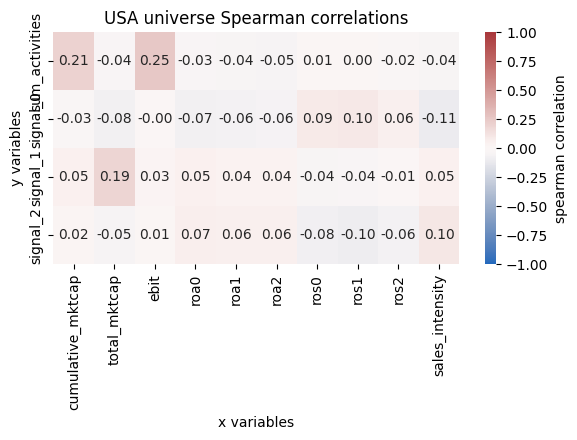

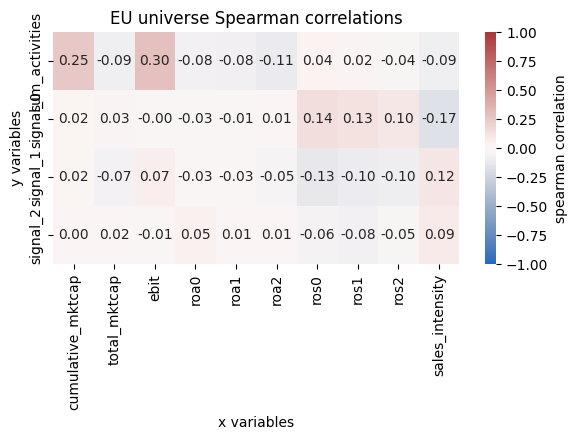

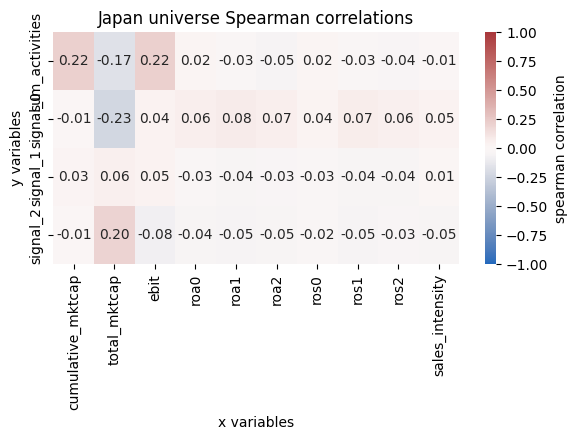

In [72]:
# Spearman version (rank correlation) for all regions
universes = {
    "USA": usa_universe,
    "EU": EU_universe,
    "Japan": Japan_universe,
}

corr_blocks_spearman = {}
for region, universe_df in universes.items():
    corr_xy, ax = corr_heatmap_xy(
        universe_df,
        y_vars=signal_columns,
        x_vars=accounting_columns,
        method="spearman",
        title=f"{region} universe Spearman correlations",
    )
    corr_blocks_spearman[region] = corr_xy

